# Assignment 3

## A bit of info before you start.


> ***First and foremost, dont use AI to code. Use it to understand and then write code yourself. Use AI to verify if the code you wrote it correct, that will help you learn far far more.***

> ***Implement Stuff from sratch. Use cv2 functions only when numpy implementation can be extremely tedious.***



You will need to use your own image for this assignment, which you need to import into here.
If you cant fetch your image from any APIs that dont need credentials, then :
To preserve an image in Google Colab without a continuous runtime or using Google Drive, you can use base64 string encoding of images ( its really simple )

First, begin by normally uploading the image into the contents folders as you normally do in colab or fetch it using Drive or any API.

To get the base64 string :
```
import base64
with open("your_image.jpg", "rb") as img_file:
    print(base64.b64encode(img_file.read()).decode())
```

Note that the base64 string is a very long string, click on the three dot icon to the left of the current code cell and click on <code> Copy Cell Output </code> to easily copy it to your clipboard.

Then, to embed the string into your Jupyter Notebook :
```
from PIL import Image
import io
import base64
import matplotlib.pyplot as plt
import numpy as np

# PASTE BASE64 STRING HERE
base64_image = "iVBORw0K..."  # long base64 string

img_data = base64.b64decode(base64_image)
img = Image.open(io.BytesIO(img_data))

plt.imshow(img)
plt.axis("off")
```
The string is really long so, use a multiline string in python ( syntax : """ """ )

Otherwise, you can also choose to use any API ( try researching on https://picsum.photos/ )

## SECTION 1 : Preparations

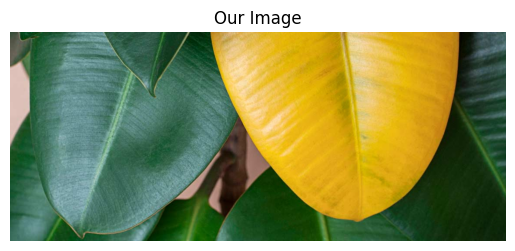

In [1]:
# @title
from PIL import Image
import io
import base64
import matplotlib.pyplot as plt
import numpy as np

img_str = """
...
"""

img_data = base64.b64decode(img_str)
img = Image.open(io.BytesIO(img_data))
img_part5 = np.array(img)

plt.imshow(img_part5)
plt.axis("off")
plt.title("Our Image")
plt.show()

## SECTION 2 : Questions

Embed your own image, the above shown is specifically for last part.

### Part A

#### Task 1 - Convolution
Write a function <code>convolve(img, kernel)</code>
Hint : Lookup <code>np.pad</code> function for padding and research how it works. It takes different modes, one that we want to use is <code>reflect</code>
Also, learn what exactly <code>*</code> does ( particularly if it can convolve matrices of different sizes and if at all you use it, then where you can and where you cannot ). Use it later on for your ease.

#### Task 2 — Average Blur

Implement a function <code>average_blur_gray(img, ksize)</code> using:
* A box kernel of size ksize × ksize
* Only NumPy (no cv2 filtering functions)

Repeat for RGB:

* Apply the kernel on each channel separately.

#### Task 3 - Gaussian Blur

1. Implement a Gaussian kernel generator:
The function signature should be <code>gaussian_kernel(ksize, sigma)</code>
It should return a numpy matrix that is the normalsied gaussian kernel with dimensions ksize x ksize and the 2D gaussian distribution calculation done with standard deviation as sigma. I had talked about it in the lecture, for any queries, research first cuz its not hard to put in values and compute.

2. Convolve it with:
* Gray image
* Each RGB channel

And, then display all results along with the original image.



(480, 1140, 3)


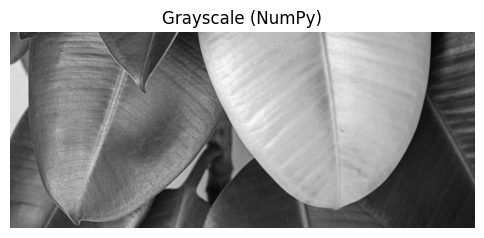

In [9]:
# Your PART A codes follow here. You can create more cells under this. Write clean and commented code.
img_np = np.array(img) # convert to NumPy
img_np = img_np[:, :, :3] # it was showing another fourth channel also for transparency.. so we just took first three.
print(img_np.shape)

R = img_np[:, :, 0].astype(np.float32)
G = img_np[:, :, 1].astype(np.float32)
B = img_np[:, :, 2].astype(np.float32)

# original image was uint8 so when we do weighted multiplication we want decimal precision, so we convert into float32.

# plotting gray scale image
gray = 0.299 * R + 0.587 * G + 0.114 * B

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale (NumPy)")
plt.axis("off")
plt.show()


In [10]:
import numpy as np

def convolve(img, kernel):
    k = kernel.shape[0]
    pad = k // 2

    # pad image
    padded = np.pad(img, pad_width=pad, mode='reflect')

    h, w = img.shape
    output = np.zeros((h, w), dtype=np.float32)

    # slide kernel
    for i in range(h):
        for j in range(w):
            region = padded[i:i+k, j:j+k]
            output[i, j] = np.sum(region * kernel)

    return output


In [11]:
def average_blur_gray(img, ksize):
    kernel = np.ones((ksize, ksize)) / (ksize * ksize)
    return convolve(img, kernel)


In [12]:
def average_blur_rgb(img, ksize):
    output = np.zeros_like(img, dtype=np.float32)

    for c in range(3):  # R, G, B
        output[:, :, c] = average_blur_gray(img[:, :, c], ksize)

    return output


In [13]:
def gaussian_kernel(ksize, sigma):
    k = ksize // 2
    kernel = np.zeros((ksize, ksize), dtype=np.float32)

    for i in range(-k, k+1):
        for j in range(-k, k+1):
            kernel[i+k, j+k] = np.exp(-(i*i + j*j) / (2 * sigma * sigma))

    # normalize
    kernel /= np.sum(kernel)
    return kernel


In [14]:
def gaussian_blur_gray(img, ksize, sigma):
    kernel = gaussian_kernel(ksize, sigma)
    return convolve(img, kernel)


In [15]:
def gaussian_blur_rgb(img, ksize, sigma):
    output = np.zeros_like(img, dtype=np.float32)

    for c in range(3):
        output[:, :, c] = gaussian_blur_gray(img[:, :, c], ksize, sigma)

    return output


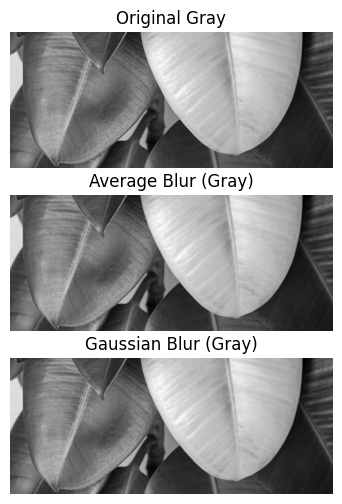

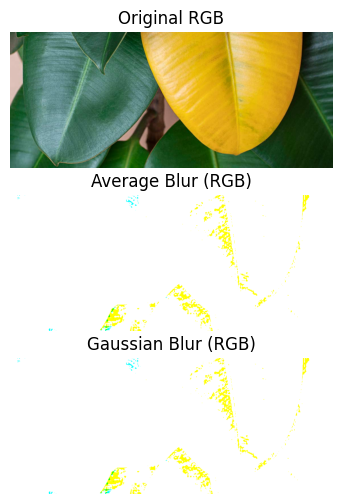

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

# Apply average blur to grayscale image
avg_blur_gray_img = average_blur_gray(gray, ksize=3)

# Apply Gaussian blur to grayscale image
gauss_blur_gray_img = gaussian_blur_gray(gray, ksize=3, sigma=1)


plt.figure(figsize=(12,6))

plt.subplot(3,1,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Gray")
plt.axis("off")

plt.subplot(3,1,2)
plt.imshow(avg_blur_gray_img, cmap='gray')
plt.title("Average Blur (Gray)")
plt.axis("off")

plt.subplot(3,1,3)
plt.imshow(gauss_blur_gray_img, cmap='gray')
plt.title("Gaussian Blur (Gray)")
plt.axis("off")

plt.show()



# Apply average blur to RGB image
avg_blur_rgb_img = average_blur_rgb(img_np, ksize=3)

# Apply Gaussian blur to RGB image
gauss_blur_rgb_img = gaussian_blur_rgb(img_np, ksize=3, sigma=5)


plt.figure(figsize=(12,6))

plt.subplot(3,1,1)
plt.imshow(img_np)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(3,1,2)
plt.imshow(avg_blur_rgb_img)
plt.title("Average Blur (RGB)")
plt.axis("off")

plt.subplot(3,1,3)
plt.imshow(gauss_blur_rgb_img)
plt.title("Gaussian Blur (RGB)")
plt.axis("off")

plt.show()

### Part B

#### Task - Sobel Edge Detection (NumPy Only)
Implement Sobel X and Sobel Y filters manually using convolution. Apply on the grayscale image.

Compute:
1. Gx
2. Gy
3. Gradient magnitude

Normalize to 0–255 and save the edge map. Threshold if you wish to, if you do then make the thresholding part clear using code comments.

In [ ]:
# Your PART B codes follow here. You can create more cells under this. Write clean and commented code.

In [33]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)


In [43]:
# Apply convolution
Gx = convolve(gray, sobel_x)
Gy = convolve(gray, sobel_y)

# Gradient magnitude
gradient_mag = np.sqrt(Gx**2 + Gy**2)

# Normalize to 0–255
gradient_mag = (gradient_mag / gradient_mag.max()) * 255
gradient_mag = gradient_mag.astype(np.uint8)


# Thresholding was applied to suppress weak edges.
threshold = 20
edge_map = gradient_mag.copy()
edge_map[edge_map < threshold] = 0

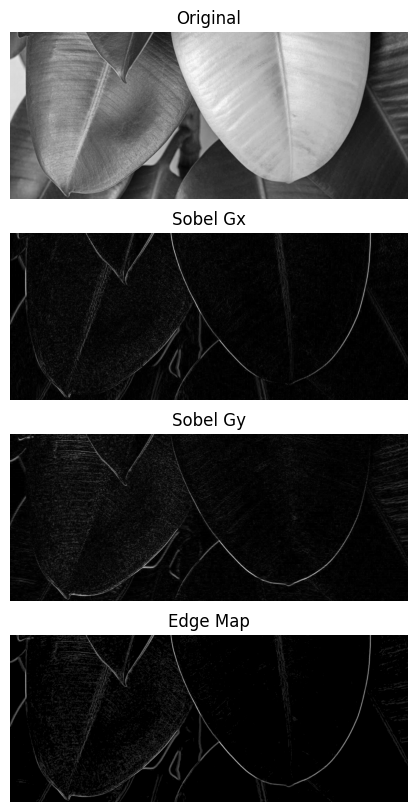

In [47]:
plt.figure(figsize=(16,10))

plt.subplot(4,1,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(4,1,2)
plt.imshow(np.abs(Gx), cmap='gray')
plt.title("Sobel Gx")
plt.axis("off")

plt.subplot(4,1,3)
plt.imshow(np.abs(Gy), cmap='gray')
plt.title("Sobel Gy")
plt.axis("off")

plt.subplot(4,1,4)
plt.imshow(edge_map, cmap='gray')
plt.title("Edge Map")
plt.axis("off")

plt.show()


### Part C

#### Task 1 — Laplacian Sharpening ( Only Numpy and Grayscale )
1. Use any 3×3 Laplacian kernel (4-connected or 8-connected).

2. Compute:
* <code>lap = convolve(img, laplacian_kernel)</code>
* <code>sharp = img - lap * alpha</code> where alpha ∈ [0.2, 1].

3. Now, put alpha = 1, if you had chosen a different value earlier. Get a new output. Then use the code in the lecture to do the same using cv2. Now, use python to verify if both numpy with alpha = 1 and cv2 give the exact same output ( Compare the matrices )

#### Task 2 - Unsharp Masking ( Only Numpy and Grayscale )
1. Apply Gaussian blur (from Part 1).
2. Subtract blurred image from original: <code> mask = img - blurred </code>
3. Add scaled mask back: <code>sharp = img + alpha * mask</code> , where you can choose any value of alpha.
4. See how negative values of alpha will give you a blurred image.  



In [ ]:
# Your PART C codes follow here. You can create more cells under this. Write clean and commented code.

In [61]:
laplacian_kernel = np.array([
    [ 0, -1,  0],
    [-1,  4, -1],
    [ 0, -1,  0]
], dtype=np.float32)

lap = convolve(gray, laplacian_kernel)
alpha = 0.5
sharp_05 = gray - alpha * lap
alpha = 1.0
sharp_1 = gray - alpha * lap

sharp_1 = np.clip(sharp_1, 0, 255).astype(np.uint8)




In [62]:
import cv2

lap_cv = cv2.Laplacian(gray, cv2.CV_32F)
sharp_cv = gray - lap_cv
sharp_cv = np.clip(sharp_cv, 0, 255).astype(np.uint8)

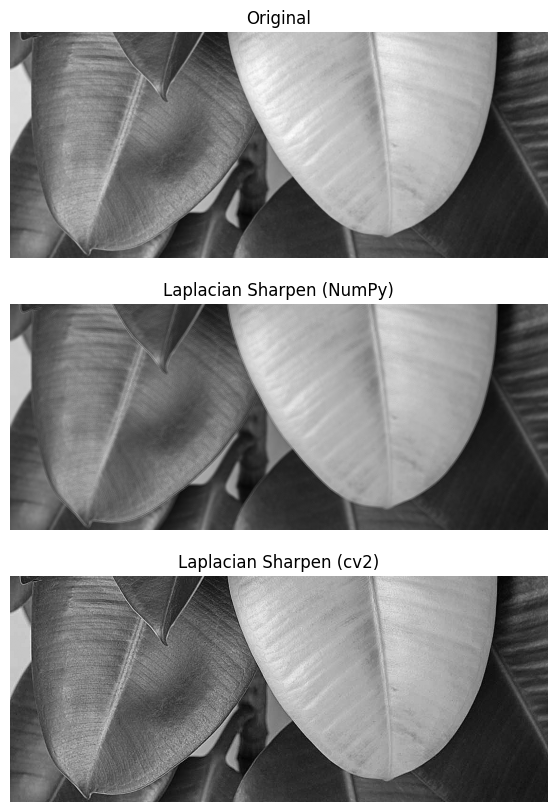

In [63]:
plt.figure(figsize=(16,10))

plt.subplot(3,1,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(3,1,2)
plt.imshow(sharp_1, cmap='gray')
plt.title("Laplacian Sharpen (NumPy)")
plt.axis("off")

plt.subplot(3,1,3)
plt.imshow(sharp_cv, cmap='gray')
plt.title("Laplacian Sharpen (cv2)")
plt.axis("off")

plt.show()


In [64]:
print( np.array_equal(sharp_1, sharp_cv))


False


In [69]:
blurred = gaussian_blur_gray(gray, ksize=5, sigma=1)
mask = gray - blurred
alpha = 0.2
sharp_unsharp = gray + alpha * mask
sharp_unsharp = np.clip(sharp_unsharp, 0, 255).astype(np.uint8)
alpha_neg = -0.7
blur_again = gray + alpha_neg * mask
blur_again = np.clip(blur_again, 0, 255).astype(np.uint8)


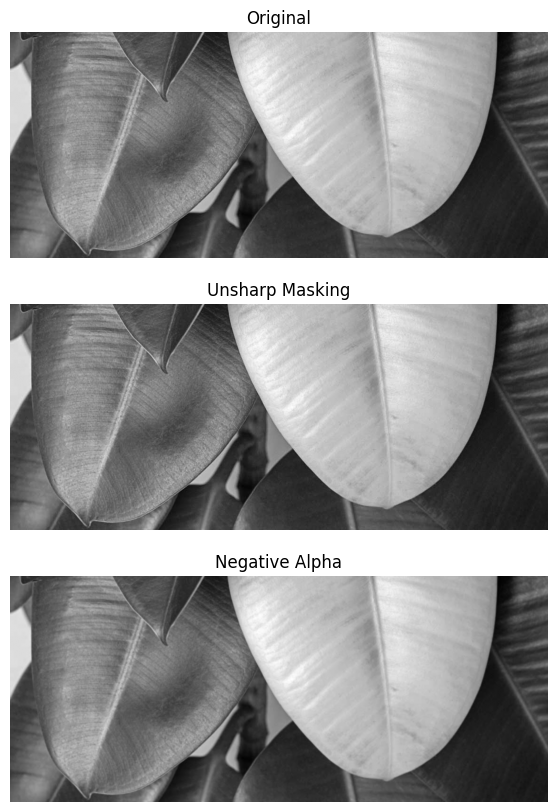

In [70]:
plt.figure(figsize=(16,10))

plt.subplot(3,1,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(3,1,2)
plt.imshow(sharp_unsharp, cmap='gray')
plt.title("Unsharp Masking")
plt.axis("off")

plt.subplot(3,1,3)
plt.imshow(blur_again, cmap='gray')
plt.title("Negative Alpha")
plt.axis("off")

plt.show()


### Part D

#### Task - Frequency Analysis (LPF & HPF Verification)
Compute the magnitude spectrum of the original image, gaussian blurred image and the unsharp masking image. Now, play with the alpha value in sharpening and gaussian kernel and notice how the magntude spectrum changes.
Then, in code comments, explain your observations of dark and bright areas in the magnitude spectrum. In nutshell, verify how convolution is actually filtering frequencies depending on the kernel.

In [ ]:
# Your PART D codes follow here. You can create more cells under this. Write clean and commented code.

In [71]:
def magnitude_spectrum(img):

    f = np.fft.fft2(img) # Compute FFT

    # Shift zero frequency to center
    fshift = np.fft.fftshift(f)

    # Magnitude spectrum (log for visibility)
    magnitude = np.log(1 + np.abs(fshift))

    return magnitude


In [74]:
spec_original = magnitude_spectrum(gray)
spec_gaussian = magnitude_spectrum(blurred)
spec_unsharp = magnitude_spectrum(sharp_unsharp)

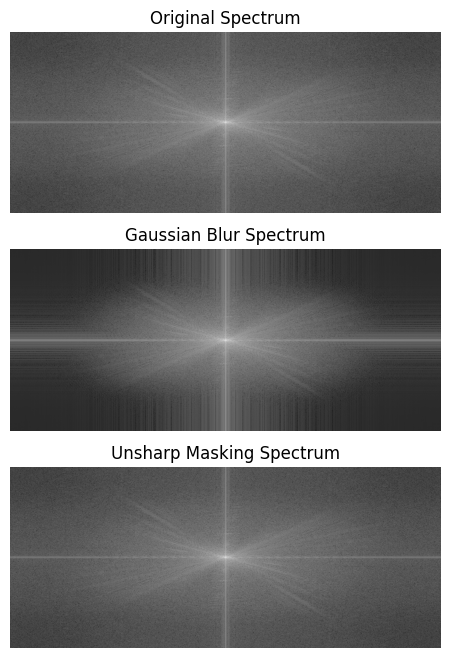

In [75]:
plt.figure(figsize=(16,8))

plt.subplot(3,1,1)
plt.imshow(spec_original, cmap='gray')
plt.title("Original Spectrum")
plt.axis("off")

plt.subplot(3,1,2)
plt.imshow(spec_gaussian, cmap='gray')
plt.title("Gaussian Blur Spectrum")
plt.axis("off")

plt.subplot(3,1,3)
plt.imshow(spec_unsharp, cmap='gray')
plt.title("Unsharp Masking Spectrum")
plt.axis("off")

plt.show()


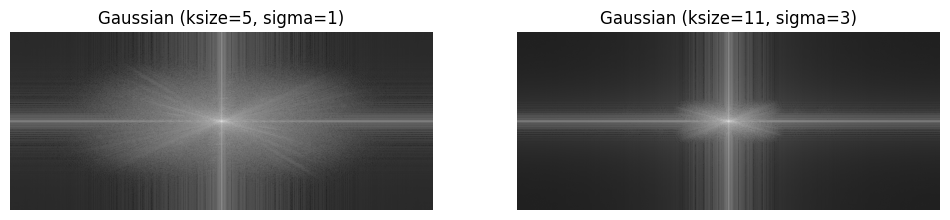

In [78]:
gauss_1 = gaussian_blur_gray(gray, ksize=5, sigma=1)
gauss_2 = gaussian_blur_gray(gray, ksize=11, sigma=3)
spec_gauss_1 = magnitude_spectrum(gauss_1)
spec_gauss_2 = magnitude_spectrum(gauss_2)
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(spec_gauss_1, cmap='gray')
plt.title("Gaussian (ksize=5, sigma=1)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(spec_gauss_2, cmap='gray')
plt.title("Gaussian (ksize=11, sigma=3)")
plt.axis("off")

plt.show()



In the left image, we see that some brightness is away from the centre and in right image, centre is very bright and outer region is almost dark.It means stronger low-pass filtering.

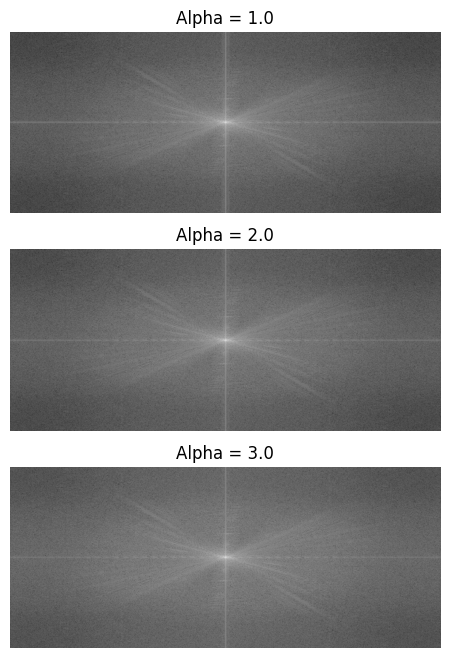

In [84]:
blur = gaussian_blur_gray(gray, ksize=5, sigma=1)
mask = gray - blur
sharp_10 = gray + 1.0 * mask
sharp_20 = gray + 2.0 * mask
sharp_30 = gray + 3.0 * mask

sharp_10 = np.clip(sharp_10, 0, 255)
sharp_20 = np.clip(sharp_20, 0, 255)
sharp_30 = np.clip(sharp_30, 0, 255)

spec_10 = magnitude_spectrum(sharp_10)
spec_20 = magnitude_spectrum(sharp_20)
spec_30 = magnitude_spectrum(sharp_30)

plt.figure(figsize=(16,8))

plt.subplot(3,1,1)
plt.imshow(spec_10, cmap='gray')
plt.title("Alpha = 1.0")
plt.axis("off")

plt.subplot(3,1,2)
plt.imshow(spec_20, cmap='gray')
plt.title("Alpha = 2.0")
plt.axis("off")

plt.subplot(3,1,3)
plt.imshow(spec_30, cmap='gray')
plt.title("Alpha = 3.0")
plt.axis("off")

plt.show()




The magnitude spectrum represents the strength of different frequency components
in the image. The center of the spectrum corresponds to low frequencies (smooth
regions), while regions farther from the center correspond to high frequencies(edges and fine details).
<br><br>
The original image shows a bright center in the magnitude spectrum, indicating
the presence of low-frequency components, along with some high-frequency content
due to edges and textures.
<br><br>
After applying Gaussian blur, the outer regions of the magnitude spectrum become
darker. This indicates suppression of high-frequency components.
Increasing the Gaussian kernel size or sigma further darkens the outer regions,
confirming that Gaussian blur acts as a low-pass filter.
<br><br>
Unsharp masking increases brightness in the high-frequency regions of the spectrum.
As the sharpening parameter alpha increases, these regions become brighter,
indicating amplification of edges and fine details.






### Part E

#### Task - Custom Colour Kernel (Detect Yellow Leaf Edges)

**Instructions :**
* At the start of the assignment .ipynb file, you will find a code cell in section 1, run it to see an image with a yellow leaf amongst green leaves.
* Design a 3×3 or 5×5 custom kernel applied separately to each channel that highlights the edges where any other colour transitions into a yellowish hue.

**Hints :**

* Yellow = (R high, G high, B low)

* Dark green = (G high, R low, B low)

**Steps:**

1. Analyze the RGB values of green & yellow regions.

2. Create a custom kernel that responds strongly to change from green to yellow in:
* Red matrices of RGB
* Green matrices of RGB
* Optionally R - G difference
* Think about the gradient in Red - Green. Is there a huge change the value of R-G when colour changes from Green to Yellow ? If yes, try to exploit it.

3. Combine the response maps.

4. Get a clean outline around the leaf.

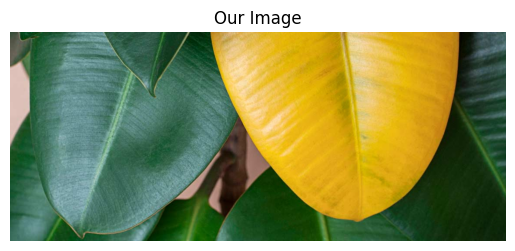

In [ ]:
plt.imshow(img_part5)
plt.axis("off")
plt.title("Our Image")
plt.show()

In [ ]:
# Your PART E codes follow here. You can create more cells under this. Write clean and commented code.

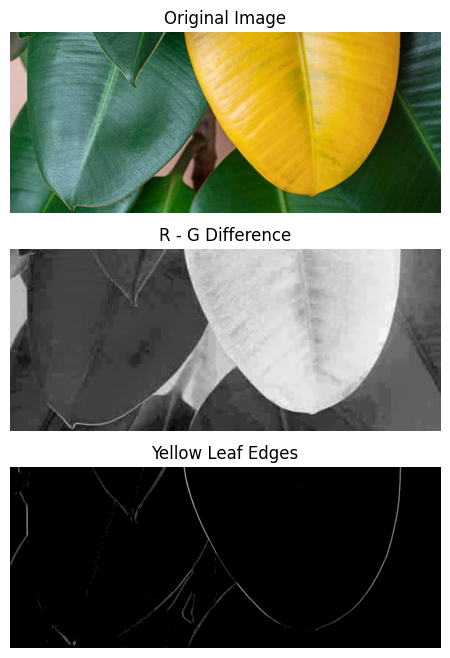

In [89]:
R = img_np[:, :, 0].astype(np.float32)
G = img_np[:, :, 1].astype(np.float32)
B = img_np[:, :, 2].astype(np.float32)

RG_diff = R - G
edge_kernel = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=np.float32)

edges_RG = convolve(RG_diff, edge_kernel)
edges_RG = np.abs(edges_RG)

edges_R = np.abs(convolve(R, edge_kernel))
edges_G = np.abs(convolve(G, edge_kernel))

combined_edges = edges_RG + 0.5 * edges_R + 0.5 * edges_G
combined_edges = (combined_edges / combined_edges.max()) * 255
combined_edges = combined_edges.astype(np.uint8)

# Threshold to get clean outline
threshold = 40
edge_map = combined_edges.copy()
edge_map[edge_map < threshold] = 0

plt.figure(figsize=(16,8))

plt.subplot(3,1,1)
plt.imshow(img_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(3,1,2)
plt.imshow(RG_diff, cmap='gray')
plt.title("R - G Difference")
plt.axis("off")

plt.subplot(3,1,3)
plt.imshow(edge_map, cmap='gray')
plt.title("Yellow Leaf Edges")
plt.axis("off")

plt.show()


Yellow regions have high Red and Green values, while green regions
have high Green but low Red values. Therefore, the difference (R - G)
changes significantly at transitions from green to yellow.<br>

By computing edges on the R-G difference image, the kernel responds
strongly at colour boundaries involving yellow hues.The edge responses from R and G channels are optionally combined to strengthen the outline and suppress noise.
Thresholding is applied to obtain a clean edge map of the yellow leaf.

### Bonus - Part F

#### Task - Color Manipulation Using Lecture 2 Concepts

**NOTE :** only for this, you can use cv2 functions, no need of doing everything in Numpy. Although there are still more brownie parts for Numpy hardwork.

1. Convert the RGB image to HSV. Use your rgb_to_hsv() from Lecture 2 Assignment - free Numopy points ;)) .
2. Identify pixels belonging to the yellow leaf using an HSV mask. (maybe take help from Part E or design a new hue mask)
3. Now use your full brain and chnage the colour of the leaf to red.

Convert back to RGB.

Display the final result.

For reference, heres the image I expect as a result. And its not actually tough, easy 5 lines code.
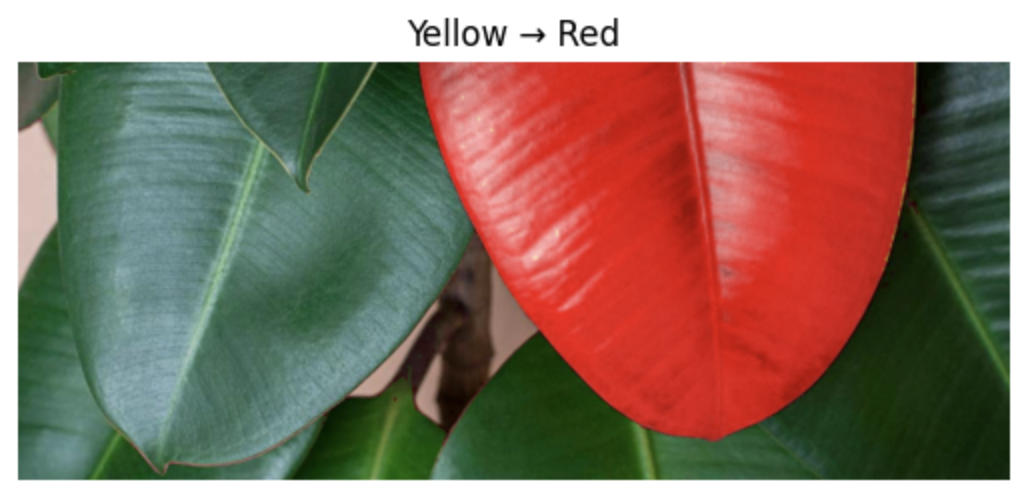

Also, we can change to a less brighter colour
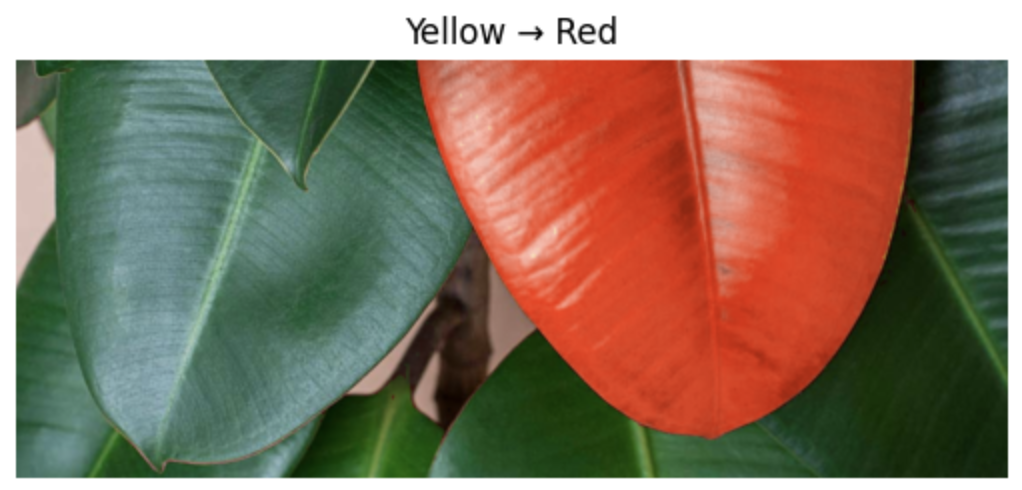

In [ ]:
# Your BONUS PART codes follow here. You can create more cells under this. Write clean and commented code.

In [92]:
import cv2

img_hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
# Define yellow range in HSV
lower_yellow = np.array([20, 100, 100])
upper_yellow = np.array([35, 255, 255])

yellow_mask = cv2.inRange(img_hsv, lower_yellow, upper_yellow)


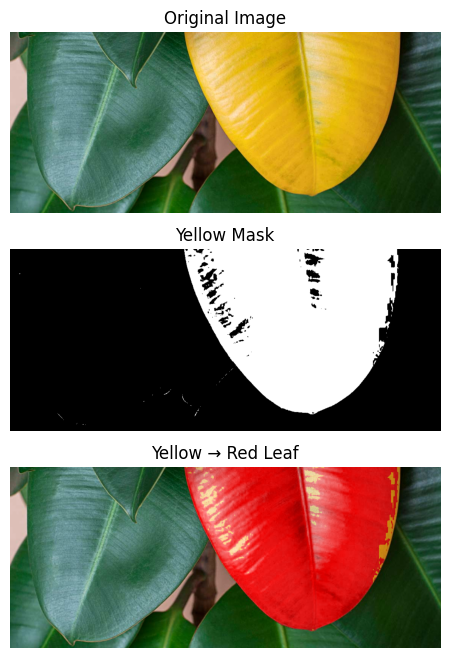

In [94]:
Hue = 0
img_hsv_modified = img_hsv.copy()

# Change hue to red where mask is true
img_hsv_modified[yellow_mask > 0, 0] = 0
img_rgb_red_leaf = cv2.cvtColor(img_hsv_modified, cv2.COLOR_HSV2RGB)
plt.figure(figsize=(16,8))

plt.subplot(3,1,1)
plt.imshow(img_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(3,1,2)
plt.imshow(yellow_mask, cmap='gray')
plt.title("Yellow Mask")
plt.axis("off")

plt.subplot(3,1,3)
plt.imshow(img_rgb_red_leaf)
plt.title("Yellow → Red Leaf")
plt.axis("off")

plt.show()

